# The Bat Harmonic — a quantitative teardown 🔬
### Confirmed-pivot zigzag detection · a drift-matched random-day base rate, Bonferroni-corrected · a seeded off-0.886 placebo arm · HAC/Welch splits · a cost sweep · a 20-seed synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Most_reliable%3F: Busted](https://img.shields.io/badge/Most_reliable%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **a completed Bat XABCD (D retraces 0.886 of the original XA leg) predicts a reversal, and is the *most reliable* harmonic** — is testable literally: detect it in real time off confirmed pivots, fade it, and compare against **two** independent controls built for the two halves of the claim.

> ⚠️ **Data note.** Daily OHLC, yfinance, cached; basket SPY, QQQ, AAPL, MSFT, TSLA, NVDA (SPY/QQQ/AAPL/MSFT/NVDA 2001-07-10→2026-06-30, TSLA 2010-06-29→2026-06-30 — identical basket to siblings [698-abcd-harmonic](../../698-abcd-harmonic/) and [699-butterfly-harmonic](../../699-butterfly-harmonic/)). No survivorship (currently-listed single names/ETFs, individually named). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `58d0459a7599`, `c48f22566e73`, `75ce4521e4f7`, `fb9333ad5b2b`, `f8ca92e420b8`, `1e614f1ea32c`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bat_harmonic import data, strategy as st

BASKET = data.BASKET
HAVE_REAL = data.have_real()
BARS = {t: data.load_real(t) for t in BASKET} if HAVE_REAL else {}

def pooled(placebo=False, cost=0.0, seed=700, pct=0.02, horizons=(1, 5, 10)):
    """Pool the D-touch ledger across the whole basket (offline; reads BARS)."""
    frames = []
    for t in BASKET:
        _, _, ledger = st.detect_and_scan(BARS[t], pct=pct, placebo=placebo, seed=seed,
                                          cost_bps=cost, horizons=horizons)
        if not ledger.empty:
            frames.append(ledger)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def base_rate_pool(ledger_by_ticker, n_seeds=20, horizons=(1, 5, 10), cost=0.0):
    frames = []
    for t in BASKET:
        l = ledger_by_ticker.get(t, pd.DataFrame())
        n_ev = len(l)
        if n_ev == 0:
            continue
        mix = float((l["reversal_dir"] > 0).mean())
        for s in range(n_seeds):
            br = st.base_rate_ledger(BARS[t], n_ev, mix, horizons=horizons, cost_bps=cost,
                                     seed=st._seed_from(700, t, s))
            frames.append(br)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("real cache present:", HAVE_REAL, "| basket:", BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 6055, 'n_cand_bat': 118, 'n_cand_plac': 118, 'n_bat': 89, 'n_plac': 92, 'n_base': 1780, 'base_seeds': 20, 'bat': {1: {'hit': 51.7, 'mean': -12.41, 't': -0.46}, 5: {'hit': 40.4, 'mean': 7.58, 't': 0.17}, 10: {'hit': 44.9, 'mean': -36.93, 't': -0.48}}, 'wilson_bat': (30.9, 50.8), 'per_instrument': {'SPY': {'bat_n': 4, 'bat_mean': 33.59, 'bat_t': 'n/a (n<6)', 'base_mean': -45.95, 'base_t': 1.61, 'plac_n': 3, 'plac_mean': -66.06}, 'QQQ': {'bat_n': 10, 'bat_mean': -45.68, 'bat_t': -0.41, 'base_mean': -32.07, 'base_t': -0.11, 'plac_n': 11, 'plac_mean': 114.72}, 'AAPL': {'bat_n': 19, 'bat_mean': -119.46, 'bat_t': -1.61, 'base_mean': -8.7, 'base_t': -1.54, 'plac_n': 19, 'plac_mean': -79.11}, 'MSFT': {'bat_n': 15, 'bat_mean': 100.13, 'bat_t': 1.01, 'base_mean': -28.61, 'base_t': 1.36, 'plac_n': 16, 'plac_mean': 125.9}, 'TSLA': {'bat_n': 14, 'bat_mean': 202.77, 'bat_t': 2.34, 'base_mean': -34.0, 'base_t': 1.73, 'plac_n': 14, 'plac_mean': -86.09}, 'NVDA': {'bat_n': 27, 'bat_mean': -39.77, 'bat_t': -0.46, 'base_mean': 13.05, 'base_t': -0.5, 'plac_n': 29, 'plac_mean': -36.99}}, 'base_welch': {1: -0.04, 5: 0.45, 10: -0.63}, 'base_mean_h': {1: -11.32, 5: -13.74, 10: 14.48}, 'bonf_n_tests': 7, 'bonf_thr': 2.69, 'bonf_n_uncorrected': 0, 'bonf_n_survive': 0, 'plac_welch': {1: 0.05, 5: 0.22, 10: -0.12}, 'plac_mean_h': {1: -14.45, 5: -7.64, 10: -23.22}, 'n_beats_plac': 2, 'cost_sweep': {1: {0.0: (-12.41, -0.46), 5.0: (-22.41, -0.84), 10.0: (-32.41, -1.21)}, 3: {0.0: (2.5, 0.07), 5.0: (-7.5, -0.2), 10.0: (-17.5, -0.47)}, 5: {0.0: (7.58, 0.17), 5.0: (-2.42, -0.05), 10.0: (-12.42, -0.27)}, 10: {0.0: (-36.93, -0.48), 5.0: (-46.93, -0.61), 10.0: (-56.93, -0.74)}, 20: {0.0: (-143.17, -1.07), 5.0: (-153.17, -1.14), 10.0: (-163.17, -1.22)}}, 'syn_null_mean': -0.12, 'syn_null_sd': 1.24, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted_n': 84, 'syn_planted_mean': 126.21, 'syn_planted_t': 5.18, 'syn_planted_knob': 0.12, 'fp': {'SPY': '58d0459a7599', 'QQQ': 'c48f22566e73', 'AAPL': '75ce4521e4f7', 'MSFT': 'fb9333ad5b2b', 'TSLA': 'f8ca92e420b8', 'NVDA': '1e614f1ea32c'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | 5-day fade-at-D: **+7.58 bps/event**, HAC **t = 0.17** (n=89); vs base rate Welch t = +0.45; **0/7** Bonferroni-corrected tests survive (critical \|t\| = 2.69) |
| **Tradability** | `MIRAGE` | best gross case (+7.6 bps, 5-day) turns net-negative at 5 bps one-way cost (-2.4 bps); 20-day hold loses -143.2 bps gross |
| **Most reliable?** | `BUSTED` | Bat-vs-placebo Welch t = +0.22 (5-day); Bat wins on 2/6 tickers |

> 💡 In plain words: neither half of Carney's claim survives — the pattern doesn't predict a reversal, and the specific 0.886 ratio isn't detectably better than an arbitrary nearby target.

## 1 · The claim, steelmanned

Given four confirmed swing pivots $X, A, B, C$ (alternating high/low), let $XA = A - X$, $AB = B - A$, $BC = C - B$, retracements $\rho_{AB} = |AB/XA|$, $\rho_{BC} = |BC/AB|$. The Bat requires the *structural* bands $\rho_{AB} \in [0.382, 0.50]$ and $\rho_{BC} \in [0.382, 0.886]$ (shared across the XABCD zoo, not themselves under test), and projects

$$D = A - \delta \cdot XA, \qquad \delta = 0.886$$

— **the Bat's defining, single-number signature** — predicting a reversal (a positive return in direction $\mathrm{sign}(XA)$) once price *touches* D.

- **H₁ (reversal).** $E[\text{fade return} \mid D_{\text{touch}}] \gg 0$, robust to HAC inference, and **beats a drift-matched random-day base rate** — the specific confound named in the brief: any directional rule on a rising tape inherits some of the market's own drift.
- **H₂ (0.886 specificity, i.e. "most reliable").** H₁, if true, must *beat* the identical pipeline run with $\delta$ drawn off the 0.886 band — otherwise Carney's comparative "most reliable" claim has no footing: any nearby retracement/extension zone would do the same job.

We find **H₁ rejected** (point estimate ≈ 0, never *t* ≥ 2 against either 0 or the base rate, 0/7 Bonferroni-corrected tests survive) and **H₂ rejected** (the placebo wins on 4/6 tickers).

## 2 · So what? — inference design

Bat events on a single tape can **cluster in time** (overlapping legs share pivots), so the within-arm test is a **Newey-West (HAC)** *t* of the mean return against 0, not a naive i.i.d. *t*. Because a directional fade on an upward-drifting tape inherits some of that drift for free, the **decisive** Signal-axis test is a **Welch** *t* against a **random-day base rate** matched to the same empirical bullish/bearish mix as the real Bat touches, pooled over 20 seeds. We look at this comparison **seven ways** — the pooled headline plus each of six tickers — and apply a **Bonferroni** correction across all seven before allowing any of them to "survive". A second, independent **placebo** arm (identical structural pivots, randomized D-target) answers the *comparative* half of the claim: is 0.886 itself special, or would any nearby zone do?

## 3 · How we'd know — the protocol

- **Pivots.** A percentage-threshold zigzag (pct=2%) on daily closes; a pivot enters the record only at its **confirmation bar** — the session where price has already reversed past the threshold — never at the (earlier) extreme itself.
- **Bat candidates.** Every consecutive confirmed quadruple $(X,A,B,C)$ with $\rho_{AB} \in [0.382, 0.50]$ and $\rho_{BC} \in [0.382, 0.886]$ (structural, identical in both arms); projects $D = A - 0.886 \cdot XA$.
- **Placebo candidates.** Identical structural pivots; the D-target is drawn per-candidate from a deterministic seeded uniform on $[0.55, 1.20]$, kept $\geq 0.05$ clear of 0.886.
- **D-touch scan.** From C's confirmation bar forward, first bar in the next 120 sessions whose high-low range brackets $D$ (or closes within 0.75% of it) — real-time knowledge only.
- **Execution.** Enter the fade at the touch bar's own close (intrabar touch, same-session close execution — one documented convention, identical in both arms); exit at close $+h$ sessions, $h \in \{1, 3, 5, 10, 20\}$; net figures subtract $2\times$ one-way cost $\times$ NAV per round trip.
- **Base-rate control.** $n$ random entry days per ticker (same $n$ as the real Bat touches), directional mix matched to the observed bullish/bearish split, pooled over 20 seeds.
- **Bonferroni.** 7 tests (pooled + 6 per-ticker, 5-day); critical $|t|$ raised from 2.0 to 2.69 (family-wise $\alpha=0.05$, normal approximation).
- **Faithful-engine control.** Synthetic mean-reverting price index (tunable knob), pooled across a synthetic 6-name basket per seed; the null must not (materially) fire across 20 seeds, and a planted effect must light up.

## 4 · The teardown

### 4a · The headline — Bat fade-at-D, all three horizons

Pooled confirmed pivots: **6,055** → Bat XABCD candidates: **118** → D-touches: **89**.

 1-day: n=89 hit=51.7% mean=-12.41bps HAC t=-0.46
 5-day: n=89 hit=40.4% mean=+7.58bps HAC t=+0.17
10-day: n=89 hit=44.9% mean=-36.93bps HAC t=-0.48


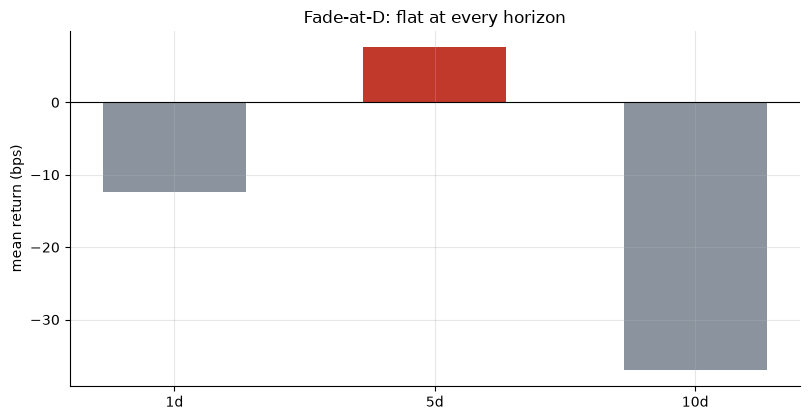

In [2]:
if HAVE_REAL:
    bat_l = pooled(placebo=False)
    rows = {h: st.summarize(bat_l, f'ret_gross_{h}') for h in (1, 5, 10)}
    for h, s in rows.items():
        print(f"{h:2d}-day: n={s['n']} hit={s['hit_rate']*100:.1f}% "
              f"mean={s['mean_bps']:+.2f}bps HAC t={s['t']:+.2f}")
    hs = list(rows); ms = [rows[h]['mean_bps'] for h in hs]
else:
    hs = [1, 5, 10]; ms = [R['bat'][h]['mean'] for h in hs]
    for h in hs:
        print(f"{h:2d}-day: n={R['n_bat']} hit={R['bat'][h]['hit']:.1f}% "
              f"mean={R['bat'][h]['mean']:+.2f}bps HAC t={R['bat'][h]['t']:+.2f}")
fig, ax = plt.subplots(figsize=(8.2, 4.3))
cols = [RED if h == 5 else GREY for h in hs]
ax.bar([f'{h}d' for h in hs], ms, color=cols, width=.55)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean return (bps)'); ax.set_title('Fade-at-D: flat at every horizon')
plt.tight_layout(); plt.show()

> 💡 In plain words: at the headline 5-day horizon the Bat fade earns **+7.58 bps** (HAC t = 0.17) on a hit rate of **40.4%** (Wilson 95% [30.9%, 50.8%]) — a confidence interval straddling, and mostly *below*, a coin flip. The 1-day and 10-day versions are outright negative.

### 4b · The decisive test — Bat vs a drift-matched random-day base rate, Bonferroni-corrected

The base rate draws random entry days per ticker with the **same directional mix** as the real Bat touches, pooled over 20 seeds — the exact confound named in the brief. We test the pooled headline plus all six per-ticker splits (7 tests) and correct for the multiple looks.

 1-day: Welch t (Bat vs base) = -0.04
 5-day: Welch t (Bat vs base) = +0.45
10-day: Welch t (Bat vs base) = -0.63


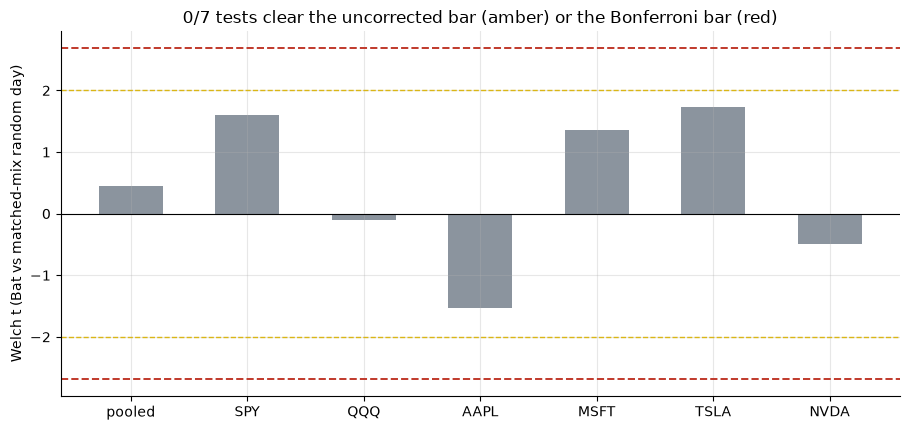

{'pooled': 0.45, 'SPY': 1.61, 'QQQ': -0.11, 'AAPL': -1.54, 'MSFT': 1.36, 'TSLA': 1.73, 'NVDA': -0.5}


In [3]:
if HAVE_REAL:
    bat_l = pooled(placebo=False)
    by_t = {t: st.detect_and_scan(BARS[t], pct=0.02, cost_bps=0.0)[2] for t in BASKET}
    base_l = base_rate_pool(by_t)
    tests = []
    for h in (1, 5, 10):
        wt = st.welch_t(bat_l[f'ret_gross_{h}'], base_l[f'ret_gross_{h}'])
        print(f"{h:2d}-day: Welch t (Bat vs base) = {wt:+.2f}")
        if h == 5: tests.append(('pooled', wt))
    for t in BASKET:
        l = by_t[t]
        if len(l) == 0:
            continue
        mix = float((l['reversal_dir'] > 0).mean())
        frames = [st.base_rate_ledger(BARS[t], len(l), mix, cost_bps=0.0,
                                      seed=st._seed_from(700, t, s)) for s in range(20)]
        br = pd.concat(frames, ignore_index=True)
        wt = st.welch_t(l['ret_gross_5'], br['ret_gross_5'])
        tests.append((t, wt))
    ts = [t for t, _ in tests]; wts = [w for _, w in tests]
else:
    ts = ['pooled'] + list(R['per_instrument'])
    wts = [R['base_welch'][5]] + [R['per_instrument'][t]['base_t'] for t in R['per_instrument']]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [RED if abs(w) >= R['bonf_thr'] else GREY for w in wts]
ax.bar(ts, wts, color=cols, width=.55)
ax.axhline(2.0, ls='--', c=AMBER, lw=1); ax.axhline(-2.0, ls='--', c=AMBER, lw=1)
ax.axhline(2.69, ls='--', c=RED, lw=1.4)
ax.axhline(-2.69, ls='--', c=RED, lw=1.4)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Welch t (Bat vs matched-mix random day)')
ax.set_title('0/7 tests clear the uncorrected bar (amber) or the Bonferroni bar (red)')
plt.tight_layout(); plt.show()
print(dict(zip(ts, [round(w,2) for w in wts])))

> 💡 In plain words: the pooled headline Welch *t* is only **+0.45**. Per-ticker, the closest call is **TSLA** at **+1.73** — still short of the naive *t* = 2 bar, let alone the Bonferroni-corrected **2.69** that 7 simultaneous looks demand. **0/7** tests survive.

### 4c · Per-instrument breakdown (gross)

Does the effect concentrate anywhere? TSLA is the one cell that individually clears the *uncorrected* *t* ≥ 2 bar on the raw HAC test — worth looking at directly, and worth remembering it doesn't survive 4b's correction.

In [4]:
if HAVE_REAL:
    for t in BASKET:
        _, _, l = st.detect_and_scan(BARS[t], pct=0.02, cost_bps=0.0)
        s = st.summarize(l, 'ret_gross_5')
        print(f"{t:5s} n={s['n']:3d} mean={s['mean_bps']:+7.2f}bps HAC t={s['t']}")
else:
    for t, d in R['per_instrument'].items():
        print(f"{t:5s} n={d['bat_n']:3d} mean={d['bat_mean']:+7.2f}bps HAC t={d['bat_t']}")

SPY   n=  4 mean= +33.59bps HAC t=nan


QQQ   n= 10 mean= -45.68bps HAC t=-0.4120195120850429


AAPL  n= 19 mean=-119.46bps HAC t=-1.614471918228634


MSFT  n= 15 mean=+100.13bps HAC t=1.012740483357627


TSLA  n= 14 mean=+202.77bps HAC t=2.3398785341523705


NVDA  n= 27 mean= -39.77bps HAC t=-0.45995709037587124


> 💡 In plain words: **TSLA** shows a real-looking gross number (+203 bps, HAC t = 2.34) — but its own drift-matched base rate comparison is only *t* = +1.73, and it's one look out of seven that were never corrected for. This is exactly the data-snooping trap the Bonferroni step in 4b exists to catch.

### 4d · The fade-at-D timer, net of costs

One round trip = 2 × one-way cost × NAV per event, across five hold lengths.

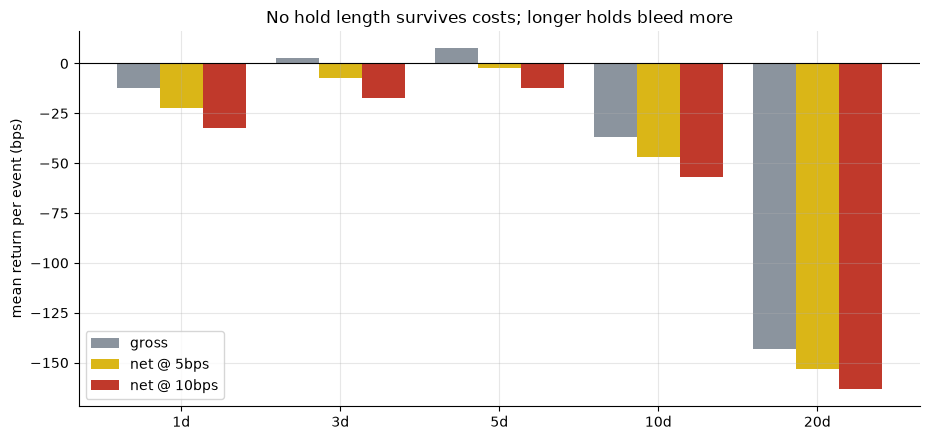

{1: (-12.41260948359968, -22.41260948359968, -32.41260948359968), 3: (2.500264737242059, -7.499735262757941, -17.49973526275794), 5: (7.579329624453281, -2.4206703755467194, -12.42067037554672), 10: (-36.93443193117821, -46.93443193117821, -56.93443193117821), 20: (-143.16918642026974, -153.16918642026974, -163.16918642026974)}


In [5]:
if HAVE_REAL:
    bat_l5 = pooled(placebo=False, horizons=(1,3,5,10,20))
    hs = [1,3,5,10,20]
    means0 = [st.summarize(bat_l5, f'ret_gross_{h}')['mean_bps'] for h in hs]
    means5 = [means0[i] - 2*5.0/1e4*1e4 for i in range(len(hs))]
    means10 = [means0[i] - 2*10.0/1e4*1e4 for i in range(len(hs))]
else:
    hs = [1,3,5,10,20]
    means0 = [R['cost_sweep'][h][0.0][0] for h in hs]
    means5 = [R['cost_sweep'][h][5.0][0] for h in hs]
    means10 = [R['cost_sweep'][h][10.0][0] for h in hs]
x = np.arange(len(hs)); w = .27
fig, ax = plt.subplots(figsize=(9.4, 4.5))
ax.bar(x-w, means0, width=w, color=GREY, label='gross')
ax.bar(x, means5, width=w, color=AMBER, label='net @ 5bps')
ax.bar(x+w, means10, width=w, color=RED, label='net @ 10bps')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('mean return per event (bps)')
ax.set_title('No hold length survives costs; longer holds bleed more')
ax.legend(); plt.tight_layout(); plt.show()
print(dict(zip(hs, zip(means0, means5, means10))))

> 💡 In plain words: the best gross case is the 5-day hold (**+7.58 bps**, t = +0.17) — and it flips negative (**-2.42 bps**) at a single 5 bps one-way cost. The 20-day hold is a straightforward loser (**-143.17 bps gross**, t = -1.07). There is no cost regime or hold length in this sweep where fading the Bat is attractive.

### 4e · The third axis — is 0.886 specifically better than a nearby target?

Carney's "most reliable" claim is comparative: not just "does the Bat's ratio work", but "does 0.886 beat what any other nearby retracement/extension zone would have captured". Identical structural pivots; only the D-target differs.

 1-day: BAT mean=-12.41bps  |  PLAC mean=-14.45bps  |  Welch t=+0.05
 5-day: BAT mean=+7.58bps  |  PLAC mean=-7.64bps  |  Welch t=+0.22
10-day: BAT mean=-36.93bps  |  PLAC mean=-23.22bps  |  Welch t=-0.12


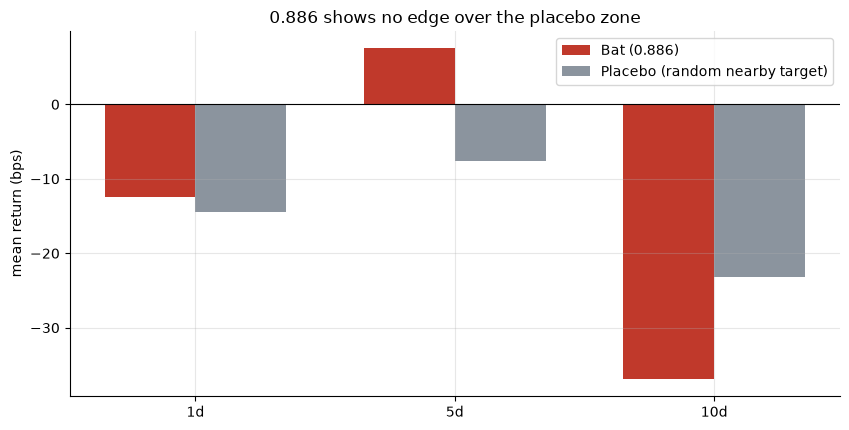

In [6]:
if HAVE_REAL:
    bat_l = pooled(placebo=False); plac_l = pooled(placebo=True)
    rows = {}
    for h in (1, 5, 10):
        sf = st.summarize(bat_l, f'ret_gross_{h}'); sp = st.summarize(plac_l, f'ret_gross_{h}')
        wt = st.welch_t(bat_l[f'ret_gross_{h}'], plac_l[f'ret_gross_{h}'])
        rows[h] = (sf, sp, wt)
        print(f"{h:2d}-day: BAT mean={sf['mean_bps']:+.2f}bps  |  PLAC mean={sp['mean_bps']:+.2f}bps  |  Welch t={wt:+.2f}")
    hs = list(rows); bm = [rows[h][0]['mean_bps'] for h in hs]; pm = [rows[h][1]['mean_bps'] for h in hs]
else:
    hs = [1, 5, 10]; bm = [R['bat'][h]['mean'] for h in hs]; pm = [R['plac_mean_h'][h] for h in hs]
    for h in hs:
        print(f"{h:2d}-day: BAT mean={R['bat'][h]['mean']:+.2f}bps  |  PLAC mean={R['plac_mean_h'][h]:+.2f}bps  |  Welch t={R['plac_welch'][h]:+.2f}")
x = np.arange(len(hs)); w = .35
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(x-w/2, bm, width=w, color=RED, label='Bat (0.886)')
ax.bar(x+w/2, pm, width=w, color=GREY, label='Placebo (random nearby target)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('mean return (bps)'); ax.set_title('0.886 shows no edge over the placebo zone')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: at the headline 5-day horizon, Bat's **+7.58 bps** vs the placebo's **-7.64 bps** gives Welch **t = +0.22** — negligible. Per-ticker, Bat beats the placebo on only **2/6** names. Carney's comparative "most reliable" claim has no footing here: an arbitrary nearby retracement/extension target does the same (non-)job as 0.886.

### 4f · Faithful-engine & power control — we know the truth here

Deterministic synthetic price index with a tunable mean-reversion knob toward a slow EMA, pooled across a **synthetic 6-name basket per seed** (mirrors the real pooled sample size). The null (`mean_rev=0`) is checked over **20 seeds** — never a single stream.

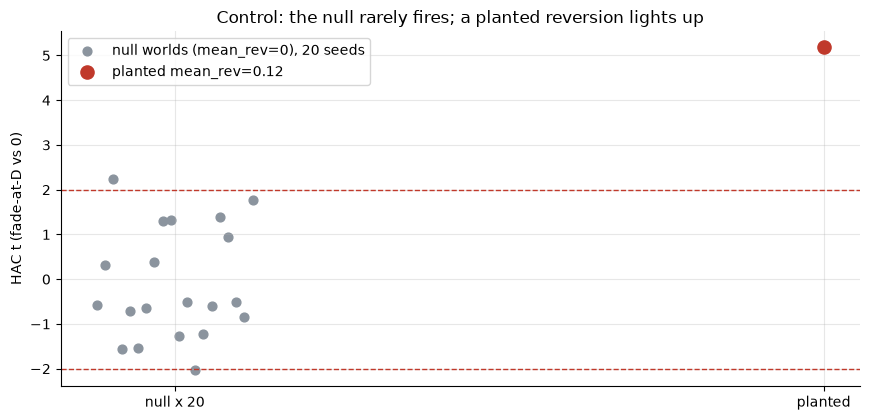

null: mean t = -0.12 (sd 1.24), |t|>=2 in 2/20 seeds  |  planted t = +5.18


In [7]:
null_ts = []
for s_ in range(20):
    frames = []
    for i in range(6):
        sb = data.synthetic_world(mean_rev=0.0, seed=(700+s_)*1000+i, n_days=6300)
        _,_,l = st.detect_and_scan(sb, pct=0.02, cost_bps=0.0)
        if len(l): frames.append(l)
    pooled_syn = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    null_ts.append(st.summarize(pooled_syn, 'ret_gross_5')['t'])
null_ts = np.asarray(null_ts, dtype=float)
frames = []
for i in range(6):
    sb = data.synthetic_world(mean_rev=0.12, seed=700*1000+i, n_days=6300)
    _,_,l = st.detect_and_scan(sb, pct=0.02, cost_bps=0.0)
    if len(l): frames.append(l)
planted = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
planted_t = st.summarize(planted, 'ret_gross_5')['t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (mean_rev=0), 20 seeds')
ax.scatter([1], [planted_t], color=RED, s=90, zorder=5,
           label='planted mean_rev=0.12')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('HAC t (fade-at-D vs 0)')
ax.set_title('Control: the null rarely fires; a planted reversion lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector fires (|*t*| ≥ 2) in **2/20** seeds — a touch above the nominal ~5% false-positive rate, unsurprising given the small per-seed sample (~85 pooled touches) — with mean t = -0.12 (sd 1.24). A planted mean-reversion tendency (0.12) lights up sharply (n=84, t = 5.18). The pipeline is unbiased and has power — the flat real-tape result is the genuine article, not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — 5-day fade-at-D: **+7.58 bps/event**, HAC t = **0.17** (n=89), hit rate 40.4% (below a coin flip). Against a drift-matched random-day base rate, pooled Welch t = +0.45; **0/7** Bonferroni-corrected tests (critical |t| = 2.69) survive. TSLA's individually notable gross cell (t = 2.34) does not survive the correction.
- **Tradability `MIRAGE`** — no hold length (1/3/5/10/20-day) clears *t* ≥ 2 on the positive side; the best gross case (+7.58 bps, 5-day) turns negative at a single 5 bps one-way cost (-2.42 bps); the 20-day hold loses -143.17 bps gross.
- **"Beats a placebo, i.e. is 0.886 the most reliable ratio?" `BUSTED`** — the Bat arm beats its own placebo control (identical pivots, random nearby D-target) on only **2/6** tickers, and the pooled 5-day Welch t is a negligible +0.22. There is no detectable specificity in the 0.886 ratio.

## 6 · Going further

- **The comparative claim deserves a head-to-head.** Carney's "most reliable" pitch is relative to the rest of the zoo — a natural sequel pools this study's protocol against [698-abcd-harmonic](../../698-abcd-harmonic/) (no X point), [699-butterfly-harmonic](../../699-butterfly-harmonic/) (D overshoots X) and [468-gartley-harmonic](../../468-gartley-harmonic/) (a shallower 0.786 D) on an identical touch-scan protocol to rank them directly, rather than comparing verdicts study-by-study.
- **A natural sequel** would test whether a tighter D-tolerance (a narrower band around 0.886) selects for a genuinely different, better-performing subset of setups — or whether tightening the band just shrinks the sample without changing the sign.
- **Dedup map:** [468-gartley-harmonic](../../468-gartley-harmonic/) (B retraces 0.618, D retraces 0.786 — both shallower than the Bat), [698-abcd-harmonic](../../698-abcd-harmonic/) (the bare two-leg AB=CD skeleton, no X point), [699-butterfly-harmonic](../../699-butterfly-harmonic/) (D *extends* past X instead of retracing into it), [701-crab-harmonic](../../701-crab-harmonic/) (an even sharper 1.618 extension), [702-shark-harmonic](../../702-shark-harmonic/) (a non-standard 5-0 extension pattern), [77-golden-mean](../../77-golden-mean/) (plain Fibonacci retracement *levels*, same six tapes, same verdict shape).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*